### Análisis de datos II
# Clase 1 - Interpretabilidad global

### Clasificación binaria

Vamos a trabajar con el dataset de Penguins y un problema de clasificación, que consiste en predecir el sexo del pinguino a partir de sus medidas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación y entrenamiento ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Interpretabilidad -------------------------------------
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE
from alibi.explainers import plot_ale

## Dataset

In [2]:
# Dataset
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Entrenamos un XGB para predecir el sexo del pingüino

In [3]:
# Variables predictoras y target
X = penguins

# Pinguino pesado / liviano
sex=penguins["sex"]
y = [1 if y_=='Male' else 0 for y_ in sex]

X = penguins.drop(columns="sex")

# Columnas categóricas y numéricas
categorical_features = ["species", "island"]
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

In [4]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Transformación
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]

In [5]:
# Modelo
model = xgb.XGBClassifier(
    objective="binary:logistic",
    max_depth=2,
    n_estimators=100,
    random_state=42
)

model.fit(X_train_trans, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
y_pred = model.predict(X_test_trans)

**Calculamos el accuracy y la matriz de confusión para ver cómo anduvo el modelo.**

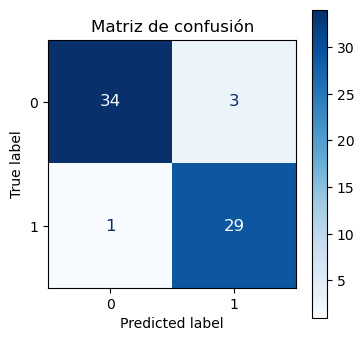


Accuracy: 0.9403


In [7]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
ax.set_title("Matriz de confusión")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

---
### Permutation Feature Importance (PFI)

In [8]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor), # transformaciones
    ("model", model)                # modelo
])

#### Calculamos "a mano" la PFI para body_mass_g.

In [9]:
X_test_perm = X_test.copy()

X_test_perm["body_mass_g"] = X_test_perm["body_mass_g"].sample(
    frac=1,
    random_state=42
).values

y_pred_perm = model_pfi.predict(X_test_perm)

acc_perm = accuracy_score(y_test, y_pred_perm)

print(f"Accuracy después de permutar body_mass_g: {acc_perm:.3f}")
print(f"Pérdida de accuracy: {acc - acc_perm:.3f}")

Accuracy después de permutar body_mass_g: 0.701
Pérdida de accuracy: 0.239


#### Calculamos PFI para todas las features de pingüinos.

In [10]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

In [11]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)

pfi

,feature,importance,std
5,body_mass_g,0.226866,0.027359
3,bill_depth_mm,0.217910,0.049592
2,bill_length_mm,0.123881,0.028358
0,species,0.077612,0.016075
4,flipper_length_mm,0.001493,0.008038
1,island,0.000000,0.000000


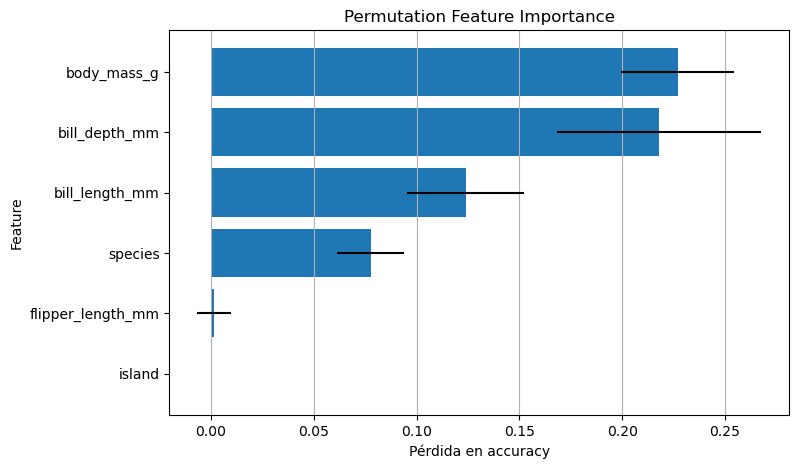

In [12]:
plt.figure(figsize=(8, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en accuracy")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

---
### Partial Dependence Plot con respecto a la longitud del pico.

En un problema de clasificación binaria, lo más habitual es hacer el PDP sobre la probabilidad de una clase (generalmente la clase positiva).

Vamos a analizar cómo cambia la probabilidad predicha de que un pingüino sea macho(clase positiva) a medida que varía `bill_length_mm`.

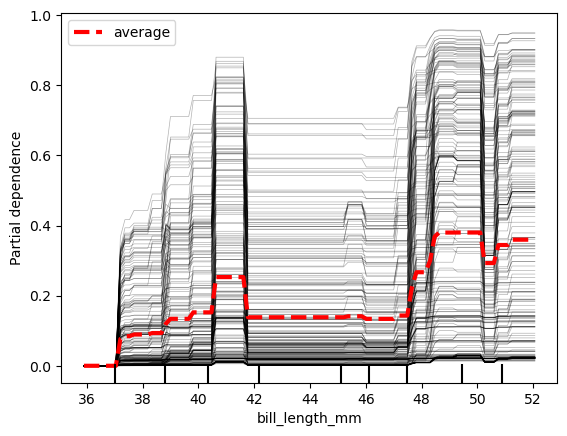

In [13]:
features=["bill_length_mm"]
PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features=features,
    feature_names=feature_names_clean,
    kind='both',
    centered= True,
    ice_lines_kw={"color": "black"},
    pd_line_kw={"color": "red","lw":3,'linestyle':'--'})
plt.show()

Podemos analizar cómo cambia la probabilidad predicha de que un pingüino sea macho según las combinaciones de `bill_length_mm` y `flipper_length_mm`.

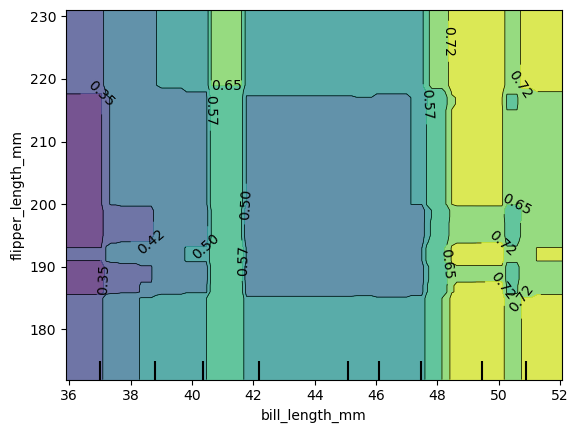

In [14]:
features = [("bill_length_mm", "flipper_length_mm")]

PartialDependenceDisplay.from_estimator(
    model,
    X_train_trans,
    features,
    feature_names=feature_names_clean,
)
plt.show()

---
### ALE

En clasificación, el modelo puede producir distintas salidas antes de asignar una clase final. Para construir un ALE plot, primero debemos decidir qué salida queremos analizar:

- **Logit / margin**: Muestra cómo una feature afecta el score interno del modelo asociado a cada una de las clases (`decision_function(X)`).

- **Probabilidad**: Muestra cómo una feature afecta la probabilidad predicha para una clase (`predict_proba(X)`).

Para plotear los ALE vamos a user la biblioteca [ALIBI EXPLAIN](https://github.com/seldonio/alibi).

### ALE en el espacio logit

Usamos ALE en el espacio logit cuando hacemos un análisis técnico, debug del comportamiento del modelo o buscamos relaciones puramente matemáticas entre las variables.

¿Cómo cambia el logit/margin del modelo cuando cambia la variable?

In [15]:
feature_names = X_train.columns.tolist()

def logit_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.predict(X_trans, output_margin=True)

logit_ale = ALE(
    logit_fun,
    feature_names=feature_names,
    target_names=["logit"]
)

logit_exp = logit_ale.explain(
    X_train.to_numpy(),
    features=[2, 3, 4]
)

Veamos la interpretación de los efectos de la longitud del pico:

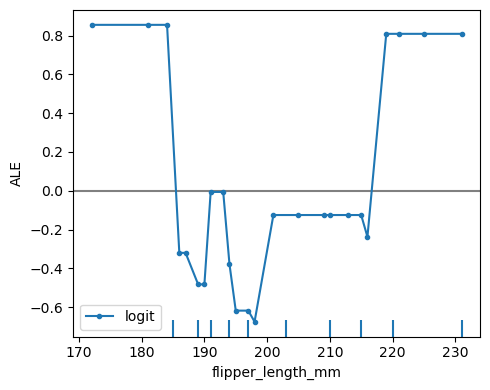

In [16]:
# features=[2] no significa columna 2 de X_train;
# significa la tercera feature de las que se pusieron en el explain, o sea flipper_length_mm.

plot_ale(logit_exp, fig_kw={'figwidth': 5, 'figheight': 4}, features=[2]);

Las unidades en los ALE plots están en logits. En un clasificador binario, el logit normalmente corresponde al score de la clase positiva.

Entonces valores positivos de ALE indican que flipper_length_mm empuja el modelo hacia la clase positiva; valores negativos, lo alejan. Vemos un efecto positivo para longitudes muy bajas, un efecto negativo entre 185–215 mm (aprox.) y nuevamente un efecto positivo para valores superiores.

**Advertencia!**

En algunas regiones hay muy pocas observaciones, por lo que esos cambios bruscos deben interpretarse con cuidado.

Podemos ver los efectos de todas las features y obtener insights análogos:

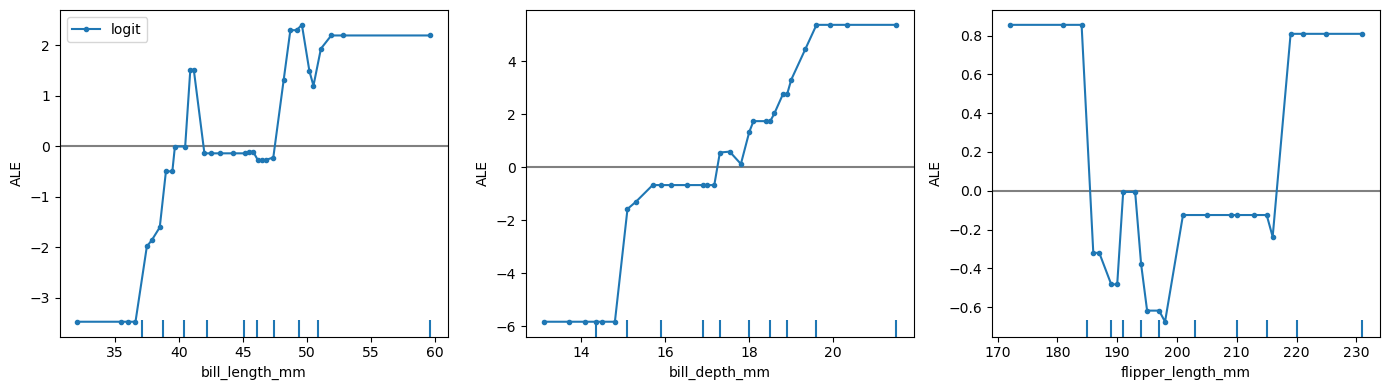

In [17]:
plot_ale(logit_exp, n_cols=3, fig_kw={'figwidth': 14, 'figheight': 4}, sharey=None);

### ALE en el espacio de probabilidades

Usamos esta opción cuando el objetivo es exponer el modelo a negocio, explicarlo a stakeholders o presentar un informe.

¿Cómo cambia la probabilidad predicha de la clase positiva cuando cambia la variable?

In [18]:
def proba_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.predict_proba(X_trans)[:, 1] # la clase 1

proba_ale = ALE(
    proba_fun,
    feature_names=feature_names,
    target_names=[model.classes_[1]]
)

proba_exp = proba_ale.explain(
    X_train.to_numpy(),
    features=[2, 3, 4]
)

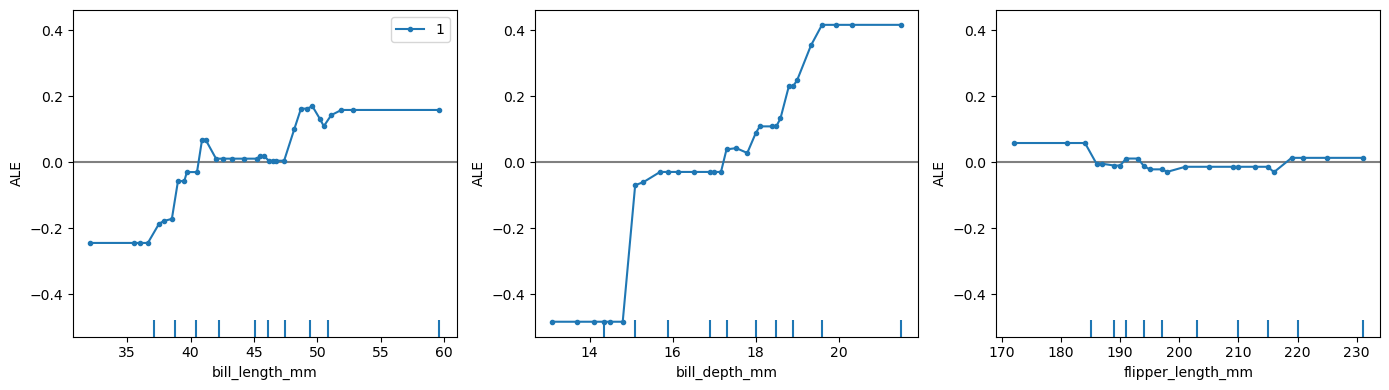

In [19]:
plot_ale(proba_exp, n_cols=3, fig_kw={'figwidth': 14, 'figheight': 4});

Los ALE están expresados en unidades de masa de probabilidad relativa: dado un valor de una feature, cuánta más (o menos) probabilidad asigna el modelo a la clase, relativo al efecto promedio de esa feature.


Ejemplo:

Los valores de bill_length_mm alrededor de 55 son ~0.2. Esto significa, que estos valores favorecen ligeramente a la clase 1 (NO significa que la probabilidad de la clase 1 sea 20%).